In [ ]:
# Import libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_fscore_support
)

import shap
import dice_ml


RANDOM_STATE = 42
DATA_PATH = "data/creditcard.csv"

In [ ]:
# Load the credit card fraud dataset
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print(df["Class"].value_counts(normalize=True))

target_col = "Class"
feature_cols = [c for c in df.columns if c != target_col]

X = df[feature_cols].copy()
y = df[target_col].copy()

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Dataset shape: (284807, 31)
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64
Train shape: (213605, 30)
Test shape: (71202, 30)


In [ ]:
# Train a Random Forest classifier
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=RANDOM_STATE
)

rf.fit(X_train, y_train)

# Evaluate model performance on the test set
proba_test = rf.predict_proba(X_test)[:, 1]
# Use predicted probabilities for ROC-AUC
print("ROC-AUC:", roc_auc_score(y_test, proba_test))


ROC-AUC: 0.9606396386844043


In [ ]:
candidate_thresholds = [0.50, 0.30, 0.20, 0.10, 0.05]
selected_threshold = None
selected_preds = None

# Find one true positive and one false positive case for explanation
for thr in candidate_thresholds:
    preds = (proba_test >= thr).astype(int)

    tp_mask = (y_test.values == 1) & (preds == 1)
    fp_mask = (y_test.values == 0) & (preds == 1)

    if tp_mask.sum() > 0 and fp_mask.sum() > 0:
        selected_threshold = thr
        selected_preds = preds
        break

if selected_threshold is None:
    raise ValueError("Could not find both a true positive and a false positive. Try more thresholds.")

print(f"Selected threshold: {selected_threshold}")

print("\nClassification report at selected threshold:")
print(classification_report(y_test, selected_preds, digits=4))

print("Confusion matrix:")
print(confusion_matrix(y_test, selected_preds))

Selected threshold: 0.5

Classification report at selected threshold:
              precision    recall  f1-score   support

           0     0.9995    1.0000    0.9997     71079
           1     0.9674    0.7236    0.8279       123

    accuracy                         0.9995     71202
   macro avg     0.9835    0.8618    0.9138     71202
weighted avg     0.9995    0.9995    0.9994     71202

Confusion matrix:
[[71076     3]
 [   34    89]]


In [21]:
test_results = X_test.copy()
test_results["y_true"] = y_test.values
test_results["proba_fraud"] = proba_test
test_results["y_pred"] = selected_preds

true_positive_cases = test_results[(test_results["y_true"] == 1) & (test_results["y_pred"] == 1)]
false_positive_cases = test_results[(test_results["y_true"] == 0) & (test_results["y_pred"] == 1)]

tp_index = true_positive_cases["proba_fraud"].sort_values(ascending=False).index[0]
fp_index = false_positive_cases["proba_fraud"].sort_values(ascending=False).index[0]

print("\nChosen TRUE POSITIVE index:", tp_index)
print("Chosen FALSE POSITIVE index:", fp_index)

print("\nTrue positive probability:", test_results.loc[tp_index, "proba_fraud"])
print("False positive probability:", test_results.loc[fp_index, "proba_fraud"])

tp_instance = X_test.loc[[tp_index]]
fp_instance = X_test.loc[[fp_index]]


Chosen TRUE POSITIVE index: 11343
Chosen FALSE POSITIVE index: 16110

True positive probability: 1.0
False positive probability: 0.97


In [22]:
shap_sample_size = min(1000, len(X_test))
X_shap_sample = X_test.sample(shap_sample_size, random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(rf)

# Compute SHAP values
shap_values_sample = explainer(X_shap_sample)

def get_positive_class_explanation(shap_exp):
    """
    Returns SHAP explanation for class 1 in binary classification.
    Works for both:
    - shape = (n_samples, n_features)
    - shape = (n_samples, n_features, n_classes)
    """
    values = shap_exp.values
    base_values = shap_exp.base_values
    data = shap_exp.data
    feature_names = shap_exp.feature_names

    if len(values.shape) == 3:
        return shap.Explanation(
            values=values[:, :, 1],
            base_values=base_values[:, 1] if len(base_values.shape) > 1 else base_values,
            data=data,
            feature_names=feature_names
        )
    return shap_exp

shap_values_sample_pos = get_positive_class_explanation(shap_values_sample)

tp_shap = get_positive_class_explanation(explainer(tp_instance))
fp_shap = get_positive_class_explanation(explainer(fp_instance))


Global SHAP bar plot


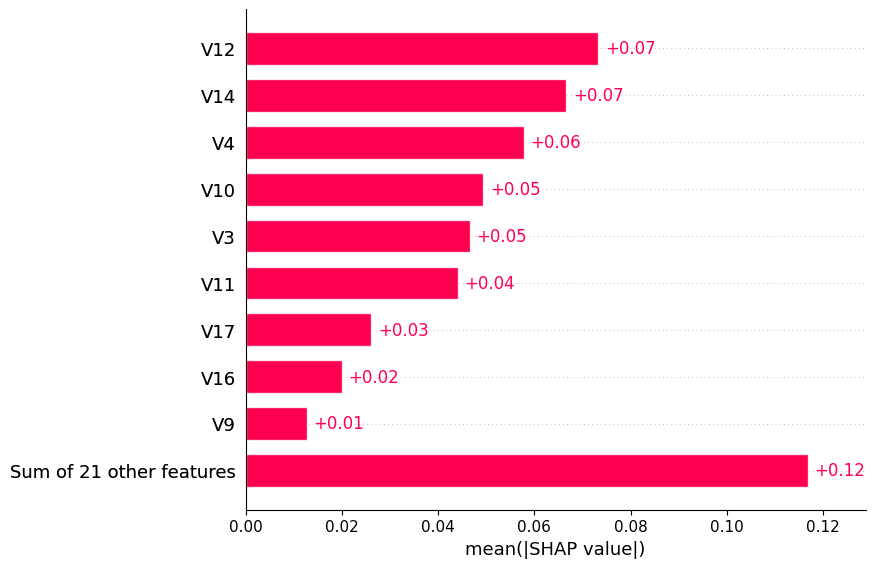


Global SHAP beeswarm plot


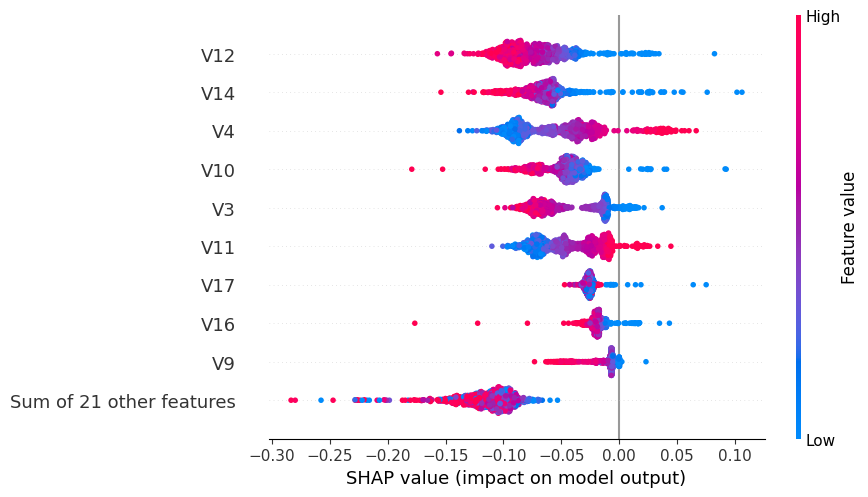

In [23]:
print("\nGlobal SHAP bar plot")
shap.plots.bar(shap_values_sample_pos, max_display=10)

print("\nGlobal SHAP beeswarm plot")
shap.plots.beeswarm(shap_values_sample_pos, max_display=10)


Waterfall plot: TRUE POSITIVE case


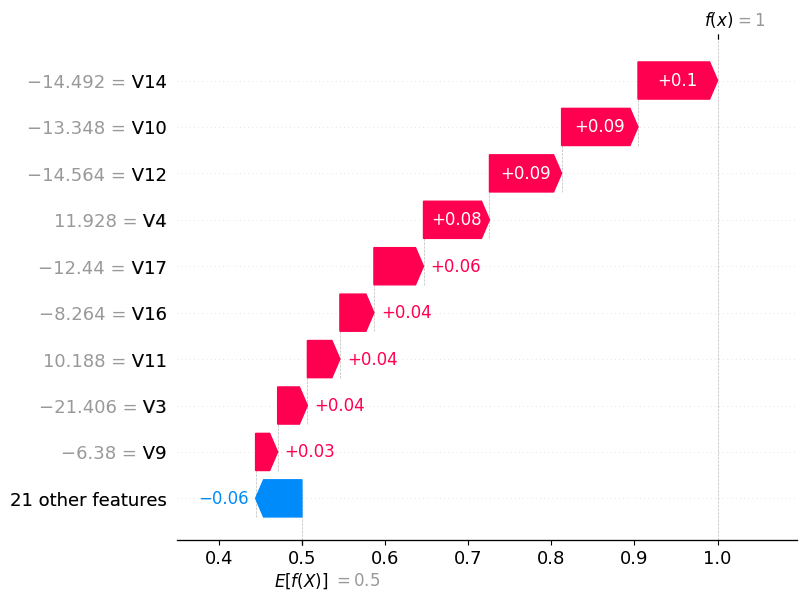


Waterfall plot: FALSE POSITIVE case


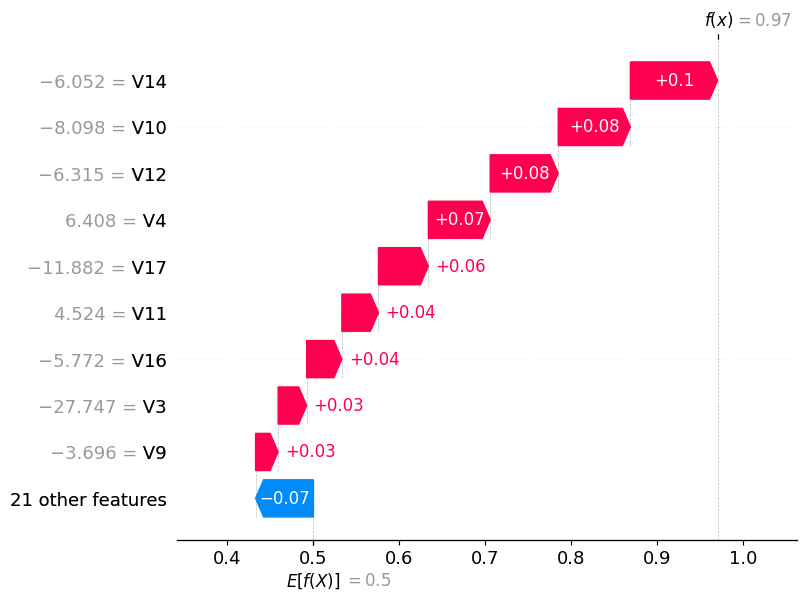

In [24]:
print("\nWaterfall plot: TRUE POSITIVE case")
shap.plots.waterfall(tp_shap[0], max_display=10)

print("\nWaterfall plot: FALSE POSITIVE case")
shap.plots.waterfall(fp_shap[0], max_display=10)

In [25]:
def top_shap_features(local_shap_exp, top_n=10):
    row = local_shap_exp[0]
    vals = pd.Series(row.values, index=row.feature_names)
    vals = vals.reindex(vals.abs().sort_values(ascending=False).index)
    return vals.head(top_n)

print("\nTop SHAP features for TRUE POSITIVE:")
print(top_shap_features(tp_shap, top_n=10))

print("\nTop SHAP features for FALSE POSITIVE:")
print(top_shap_features(fp_shap, top_n=10))


Top SHAP features for TRUE POSITIVE:
V14    0.095771
V10    0.091888
V12    0.086764
V4     0.079351
V17    0.059636
V16    0.040926
V11    0.039108
V3     0.035783
V9     0.026525
V7     0.018776
dtype: float64

Top SHAP features for FALSE POSITIVE:
V14    0.101391
V10    0.083935
V12    0.079097
V4     0.071938
V17    0.058046
V11    0.042517
V16    0.040941
V3     0.033180
V9     0.026208
V22   -0.022982
dtype: float64


In [ ]:
# Prepare DiCE for counterfactual explanations
train_for_dice = X_train.copy()
train_for_dice[target_col] = y_train.values

continuous_features = feature_cols

dice_data = dice_ml.Data(
    dataframe=train_for_dice,
    continuous_features=continuous_features,
    outcome_name=target_col
)

dice_model = dice_ml.Model(
    model=rf,
    backend="sklearn",
    model_type="classifier"
)

dice = dice_ml.Dice(dice_data, dice_model, method="random")

In [ ]:
# Generate counterfactual examples for both selected cases
print("\nGenerating counterfactuals for FALSE POSITIVE...")
fp_cf = dice.generate_counterfactuals(
    fp_instance,
    total_CFs=3,
    desired_class=0,
    features_to_vary="all"
)

print("\nGenerating counterfactuals for TRUE POSITIVE...")
tp_cf = dice.generate_counterfactuals(
    tp_instance,
    total_CFs=3,
    desired_class=0,
    features_to_vary="all"
)


Generating counterfactuals for FALSE POSITIVE...


100%|██████████| 1/1 [00:03<00:00,  3.96s/it]



Generating counterfactuals for TRUE POSITIVE...


100%|██████████| 1/1 [00:03<00:00,  3.35s/it]


In [28]:
def changed_features_table(original_df, cf_df, top_n=None, atol=1e-9):
    """
    Returns a compact table with only changed features
    between the original instance and each counterfactual.
    """
    original = original_df.iloc[0]
    rows = []

    for cf_idx in range(len(cf_df)):
        cf_row = cf_df.iloc[cf_idx]

        for col in original.index:
            if col == target_col:
                continue

            if not np.isclose(original[col], cf_row[col], atol=atol):
                rows.append({
                    "CF": f"CF {cf_idx + 1}",
                    "Feature": col,
                    "Original": original[col],
                    "Counterfactual": cf_row[col]
                })

    result = pd.DataFrame(rows)

    if top_n is not None and not result.empty:
        result["AbsChange"] = (result["Counterfactual"] - result["Original"]).abs()
        result = (
            result.sort_values(["CF", "AbsChange"], ascending=[True, False])
                  .groupby("CF", as_index=False)
                  .head(top_n)
                  .drop(columns="AbsChange")
        )

    return result


print("\nFALSE POSITIVE original fraud probability:",
      rf.predict_proba(fp_instance)[0, 1])
print("TRUE POSITIVE original fraud probability:",
      rf.predict_proba(tp_instance)[0, 1])

fp_cf_df = fp_cf.cf_examples_list[0].final_cfs_df
tp_cf_df = tp_cf.cf_examples_list[0].final_cfs_df

print("\nFALSE POSITIVE - changed features only:")
fp_changed = changed_features_table(fp_instance, fp_cf_df, top_n=3)
display(fp_changed)

print("\nTRUE POSITIVE - changed features only:")
tp_changed = changed_features_table(tp_instance, tp_cf_df, top_n=3)
display(tp_changed)


FALSE POSITIVE original fraud probability: 0.97
TRUE POSITIVE original fraud probability: 1.0

FALSE POSITIVE - changed features only:


,CF,Feature,Original,Counterfactual
0,CF 1,V11,4.524322,-3.604131
1,CF 2,V14,-6.052126,-0.206241
3,CF 3,V21,1.853209,-30.648326
2,CF 3,V11,4.524322,-3.791084



TRUE POSITIVE - changed features only:


,CF,Feature,Original,Counterfactual
0,CF 1,V2,7.421370,-70.294238
1,CF 1,V9,-6.380125,13.666404
2,CF 2,V4,11.927512,-5.447818
3,CF 2,V9,-6.380125,6.773700
4,CF 3,V12,-14.563980,2.002662


In [29]:
def compare_instance_to_cf(original_df, cf_df, atol=1e-9):
    original = original_df.iloc[0]
    comparisons = []

    for i in range(len(cf_df)):
        cf_row = cf_df.iloc[i]
        changed = []
        for col in original.index:
            if col == target_col:
                continue
            if not np.isclose(original[col], cf_row[col], atol=atol):
                changed.append((col, original[col], cf_row[col]))
        comparisons.append(changed)
    return comparisons

print("\nChanged features in FALSE POSITIVE counterfactuals:")
fp_changes = compare_instance_to_cf(fp_instance, fp_cf.cf_examples_list[0].final_cfs_df)
for i, ch in enumerate(fp_changes, start=1):
    print(f"\nCF {i}:")
    for item in ch[:10]:
        print(item)

print("\nChanged features in TRUE POSITIVE counterfactuals:")
tp_changes = compare_instance_to_cf(tp_instance, tp_cf.cf_examples_list[0].final_cfs_df)
for i, ch in enumerate(tp_changes, start=1):
    print(f"\nCF {i}:")
    for item in ch[:10]:
        print(item)


Changed features in FALSE POSITIVE counterfactuals:

CF 1:
('V11', np.float64(4.5243215285123), np.float64(-3.60413054))

CF 2:
('V14', np.float64(-6.05212557763744), np.float64(-0.2062406))

CF 3:
('V11', np.float64(4.5243215285123), np.float64(-3.79108406))
('V21', np.float64(1.85320904035127), np.float64(-30.64832631))

Changed features in TRUE POSITIVE counterfactuals:

CF 1:
('V2', np.float64(7.42136996239257), np.float64(-70.294238))
('V9', np.float64(-6.38012489838839), np.float64(13.66640355))

CF 2:
('V4', np.float64(11.927511869244), np.float64(-5.44781784))
('V9', np.float64(-6.38012489838839), np.float64(6.7737))

CF 3:
('V12', np.float64(-14.5639797552132), np.float64(2.0026619))


In [30]:
tp_prob = rf.predict_proba(tp_instance)[0, 1]
fp_prob = rf.predict_proba(fp_instance)[0, 1]

print("\nTRUE POSITIVE fraud probability:", tp_prob)
print("FALSE POSITIVE fraud probability:", fp_prob)


TRUE POSITIVE fraud probability: 1.0
FALSE POSITIVE fraud probability: 0.97
